# Solving CartPole-v1 with PPO (from scratch)

This notebook demonstrates how to solve the CartPole-v1 environment using a custom implementation of the Proximal Policy Optimization (PPO) algorithm in PyTorch. No external RL libraries are used.

## 1. Install and Import Required Libraries
We will use gymnasium and torch for this implementation.

In [11]:
# Install and import required libraries
import sys
import subprocess

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

try:
    import gymnasium as gym
except ImportError:
    install("gymnasium")
    import gymnasium as gym

try:
    import torch
except ImportError:
    install("torch")
    import torch

import numpy as np
import torch.nn as nn
import torch.optim as optim

## 2. Set Up CartPole-v1 Environment
We will initialize the CartPole-v1 environment and display its basic information.

In [12]:
# Set up the LunarLander-v3 environment
env = gym.make("LunarLander-v3")
obs_dim = env.observation_space.shape[0]
act_dim = env.action_space.n
print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")

Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space: Discrete(4)


## 3. Implement PPO Agent
We will define the policy and value networks, and the PPO update step.

In [ ]:
# Policy and Value Networks
class PolicyNet(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, act_dim)
        )
    def forward(self, x):
        return self.net(x)

class ValueNet(nn.Module):
    def __init__(self, obs_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.net(x)

## 4. Train PPO Agent
We will train the PPO agent on CartPole-v1.

In [14]:
from torch.distributions.categorical import Categorical

# TODO: generalize into method that can also render N episodes
def evaluate_policy(policy, env_name="LunarLander-v3", n_episodes=20):
    rewards = []
    eval_env = gym.make(env_name)
    eval_seed = np.random.randint(0, 1000000)
    obs, info = eval_env.reset(seed=eval_seed)
    for ep in range(n_episodes):
        done = False
        ep_reward = 0
        while not done:
            obs_t = torch.as_tensor(obs, dtype=torch.float32)
            logits = policy(obs_t)
            dist = Categorical(logits=logits)
            action = dist.sample().item()
            #action = dist.probs.argmax().item()
            obs, reward, terminated, truncated, info = eval_env.step(action)
            done = terminated or truncated
            ep_reward += reward
        rewards.append(ep_reward)
        obs, info = eval_env.reset()
    mean_reward = np.mean(rewards)
    return mean_reward, rewards

evaluate_policy(PolicyNet(obs_dim, act_dim), n_episodes=5)

(np.float64(-187.4250194927831),
 [np.float64(-240.91025356535349),
  np.float64(-76.92279399250745),
  np.float64(-209.65084726963528),
  np.float64(-198.45392861775102),
  np.float64(-211.1872740186683)])

In [ ]:
# Helper functions for PPO
import matplotlib.pyplot as plt
import random

def set_global_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def compute_gae(rewards, values, dones, gamma=0.99, lam=0.95):
    advantages = []
    gae = 0
    values = values + [0]
    for t in reversed(range(len(rewards))):
        delta = rewards[t] + gamma * values[t+1] * (1 - dones[t]) - values[t]
        gae = delta + gamma * lam * (1 - dones[t]) * gae
        advantages.insert(0, gae)
    return advantages

# Set fixed seed for training
TRAIN_SEED = 42
set_global_seed(TRAIN_SEED)
obs, info = env.reset(seed=TRAIN_SEED)

# PPO Training Loop
policy = PolicyNet(obs_dim, act_dim)
value = ValueNet(obs_dim)
policy_optim = optim.Adam(policy.parameters(), lr=1e-4)
value_optim = optim.Adam(value.parameters(), lr=5e-4)

clip_epsilon = 0.15
minibatch_size = 128
gamma = 0.98
lam = 0.92
episodes_per_epoch = 20  # Increased for more stable updates
eval_interval = 5  # Evaluate every n epochs
eval_episodes = 20  # Number of episodes for evaluation
reward_threshold = 200  # LunarLander-v3 solved threshold
#max_epochs = 200  # Safety cap

train_rewards = []  # Store mean reward per epoch
solved = False
current_epoch = 0

while not solved:# and current_epoch < max_epochs:
    obs_buf, act_buf, adv_buf, ret_buf, logp_buf = [], [], [], [], []
    val_buf, rew_buf, done_buf = [], [], []
    episode_rewards = []
    episodes_collected = 0
    obs, info = env.reset()
    done = False
    ep_rews = []
    while episodes_collected < episodes_per_epoch:
        obs_t = torch.as_tensor(obs, dtype=torch.float32)
        logits = policy(obs_t)
        dist = Categorical(logits=logits)
        action = dist.sample()
        logp = dist.log_prob(action)
        value_pred = value(obs_t).item()
        next_obs, reward, terminated, truncated, info = env.step(action.item())
        done_flag = terminated or truncated
        obs_buf.append(obs)
        act_buf.append(action.item())
        logp_buf.append(logp.item())
        val_buf.append(value_pred)
        rew_buf.append(reward)
        done_buf.append(done_flag)
        obs = next_obs
        ep_rews.append(reward)
        if done_flag:
            episode_rewards.append(sum(ep_rews))
            obs, info = env.reset()
            ep_rews = []
            episodes_collected += 1
    if ep_rews:
        episode_rewards.append(sum(ep_rews))
    train_rewards.append(np.mean(episode_rewards))
    adv_buf = compute_gae(rew_buf, val_buf, done_buf, gamma, lam)
    ret_buf = (np.array(adv_buf) + np.array(val_buf)).tolist()
    # Convert buffers to tensors
    obs_tensor = torch.as_tensor(np.array(obs_buf), dtype=torch.float32)
    act_tensor = torch.as_tensor(np.array(act_buf), dtype=torch.int64)
    adv_tensor = torch.as_tensor(np.array(adv_buf), dtype=torch.float32)
    ret_tensor = torch.as_tensor(np.array(ret_buf), dtype=torch.float32)
    logp_old_tensor = torch.as_tensor(np.array(logp_buf), dtype=torch.float32)
    # Normalize advantages
    adv_tensor = (adv_tensor - adv_tensor.mean()) / (adv_tensor.std() + 1e-8)
    # PPO update
    num_samples = len(obs_buf)
    for _ in range(10):
        idx = np.random.permutation(num_samples)
        for start in range(0, num_samples, minibatch_size):
            end = start + minibatch_size
            mb_idx = idx[start:end]
            logits = policy(obs_tensor[mb_idx])
            dist = Categorical(logits=logits)
            logp = dist.log_prob(act_tensor[mb_idx])
            ratio = torch.exp(logp - logp_old_tensor[mb_idx])
            surr1 = ratio * adv_tensor[mb_idx]
            surr2 = torch.clamp(ratio, 1 - clip_epsilon, 1 + clip_epsilon) * adv_tensor[mb_idx]
            policy_loss = -torch.min(surr1, surr2).mean()
            value_pred = value(obs_tensor[mb_idx]).squeeze()
            value_loss = ((ret_tensor[mb_idx] - value_pred) ** 2).mean()
            policy_optim.zero_grad()
            policy_loss.backward()
            policy_optim.step()
            value_optim.zero_grad()
            value_loss.backward()
            value_optim.step()
    current_epoch += 1
    print(f"Epoch {current_epoch} complete. Mean train reward: {train_rewards[-1]:.2f}")
    if current_epoch % eval_interval == 0:
        mean_eval_reward, _ = evaluate_policy(policy, n_episodes=eval_episodes)
        print(f"Evaluation after {current_epoch} epochs: Mean reward = {mean_eval_reward:.2f}")
        if mean_eval_reward >= reward_threshold:
            print(f"Solved! Mean evaluation reward {mean_eval_reward:.2f} >= {reward_threshold}")
            solved = True

Epoch 1 complete. Mean train reward: -171.05
Epoch 2 complete. Mean train reward: -229.97
Epoch 3 complete. Mean train reward: -227.46
Epoch 4 complete. Mean train reward: -221.35
Epoch 5 complete. Mean train reward: -166.10
Evaluation after 5 epochs: Mean reward = -112.39
Epoch 6 complete. Mean train reward: -121.32
Epoch 7 complete. Mean train reward: -170.66
Epoch 8 complete. Mean train reward: -114.79
Epoch 9 complete. Mean train reward: -107.14
Epoch 10 complete. Mean train reward: -91.79
Evaluation after 10 epochs: Mean reward = -86.19
Epoch 11 complete. Mean train reward: -105.76
Epoch 12 complete. Mean train reward: -65.61
Epoch 13 complete. Mean train reward: -41.12
Epoch 14 complete. Mean train reward: -51.56
Epoch 15 complete. Mean train reward: -145.63
Evaluation after 15 epochs: Mean reward = -80.91
Epoch 16 complete. Mean train reward: -53.89
Epoch 17 complete. Mean train reward: -64.98
Epoch 18 complete. Mean train reward: -71.16
Epoch 19 complete. Mean train reward: -32

KeyboardInterrupt: 

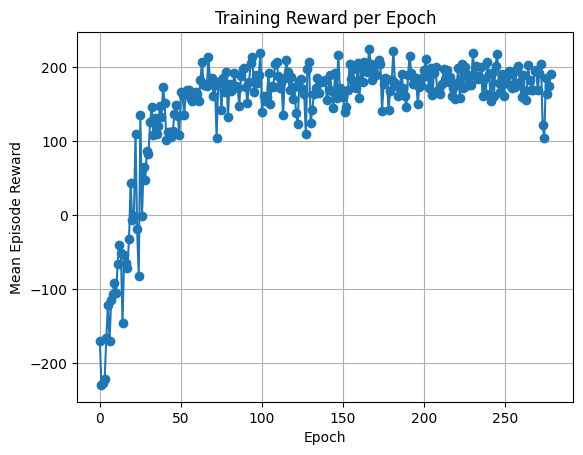

In [16]:
# Plot training rewards after training
import matplotlib.pyplot as plt
plt.plot(train_rewards, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Mean Episode Reward')
plt.title('Training Reward per Epoch')
plt.grid(True)
plt.show()


In [17]:
evaluate_policy(policy, n_episodes=100)

KeyboardInterrupt: 

In [ ]:
%pip install tsilva-notebook-utils

Note: you may need to restart the kernel to use updated packages.


In [18]:
from tsilva_notebook_utils.gymnasium import render_episode
from tsilva_notebook_utils.gymnasium import build_env

build_env_fn = lambda **kwargs: build_env("LunarLander-v3", **kwargs)

render_episode(
    env=build_env_fn,
    model=policy
)